# 🚦 Análise de Acidentes de Trânsito — Grande Vitória & ES
**Projeto Integrador III · Ciência da Computação · FAESA**

**Equipe:** Gabriel Dazilio Fanchiotti · Devandro Munaldi Junior · Ramiro Biazatti Rocha  
**Orientadores:** Prof. Howard Roatti · Prof. Wesley Pereira da Silva  
**Fonte dos dados:** Polícia Rodoviária Federal (PRF) — `datatran2025.csv`

---

## Estrutura do Notebook
1. Importações e configurações
2. Carregamento e limpeza dos dados
3. Visão geral (KPIs)
4. Análise Temporal
5. Análise Espacial
6. Análise Causal
7. Machine Learning — Classificação de Risco
8. Conclusões

## 1. Importações e Configurações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

#Estilo dos graficos
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'
COR_PRINCIPAL = '#1B518F'
COR_ACENTO    = '#F5A623'
COR_PERIGO    = '#E74C3C'
PALETTE       = [COR_PRINCIPAL, COR_ACENTO, COR_PERIGO, '#27AE60', '#8E44AD']

print('Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 2. Carregamento e Limpeza dos Dados

In [ ]:
#Ajuste o caminho se necessario
CAMINHO_CSV = 'datatran2025.csv'

df_raw = pd.read_csv(CAMINHO_CSV, sep=';', encoding='latin1')
print(f'Total de registros (Brasil): {len(df_raw):,}')
print(f'Colunas disponíveis: {list(df_raw.columns)}')

📦 Total de registros (Brasil): 72,529
📋 Colunas disponíveis: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


In [ ]:
#Filtrar apenas Espirito Santo
df = df_raw[df_raw['uf'] == 'ES'].copy()

#Converter data e hora
df['data'] = pd.to_datetime(df['data_inversa'], errors='coerce')
df['mes']  = df['data'].dt.month
df['hora'] = pd.to_numeric(df['horario'].str[:2], errors='coerce')

#Corrigir latitude/longitude (vírgula → ponto)
df['lat'] = pd.to_numeric(df['latitude'].str.replace(',', '.'), errors='coerce')
df['lon'] = pd.to_numeric(df['longitude'].str.replace(',', '.'), errors='coerce')

#Municipios da Grande Vitoria
GRANDE_VITORIA = ['VITORIA', 'VILA VELHA', 'CARIACICA', 'SERRA', 'VIANA', 'GUARAPARI', 'FUNDAO']
df['grande_vitoria'] = df['municipio'].isin(GRANDE_VITORIA)

#Classificação binaria de risco
df['risco'] = df['classificacao_acidente'].replace({
    'Com Vítimas Fatais': 'Alto Risco',
    'Com Vítimas Feridas': 'Médio Risco',
    'Sem Vítimas': 'Baixo Risco'
})

print(f'Registros no ES: {len(df):,}')
print(f'Municípios únicos: {df["municipio"].nunique()}')
print(f'Grande Vitória: {df["grande_vitoria"].sum()} acidentes')
print(f'Período: {df["data"].min().date()} a {df["data"].max().date()}')
df.head(3)

✅ Registros no ES: 2,642
   Municípios únicos: 38
   Grande Vitória: 1144 acidentes
   Período: 2025-01-01 a 2025-12-31


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,regional,delegacia,uop,data,mes,hora,lat,lon,grande_vitoria,risco
23,652761,2025-01-02,quinta-feira,13:20:00,ES,262,"73,2",MARECHAL FLORIANO,Reação tardia ou ineficiente do condutor,Colisão com objeto,...,SPRF-ES,DEL01-ES,UOP02-DEL01-ES,2025-01-02,1,13,-20.410664,-40.883802,False,Baixo/Médio Risco
42,652869,2025-01-03,sexta-feira,05:03:00,ES,101,"294,5",CARIACICA,Ausência de reação do condutor,Engavetamento,...,SPRF-ES,DEL01-ES,UOP01-DEL01-ES,2025-01-03,1,5,-20.324159,-40.395290,True,Baixo/Médio Risco
61,652976,2025-01-03,sexta-feira,17:00:00,ES,101,301,VIANA,Demais falhas mecânicas ou elétricas,Colisão traseira,...,SPRF-ES,DEL01-ES,UOP01-DEL01-ES,2025-01-03,1,17,-20.368256,-40.444064,True,Baixo/Médio Risco


## 3. Visão Geral — KPIs

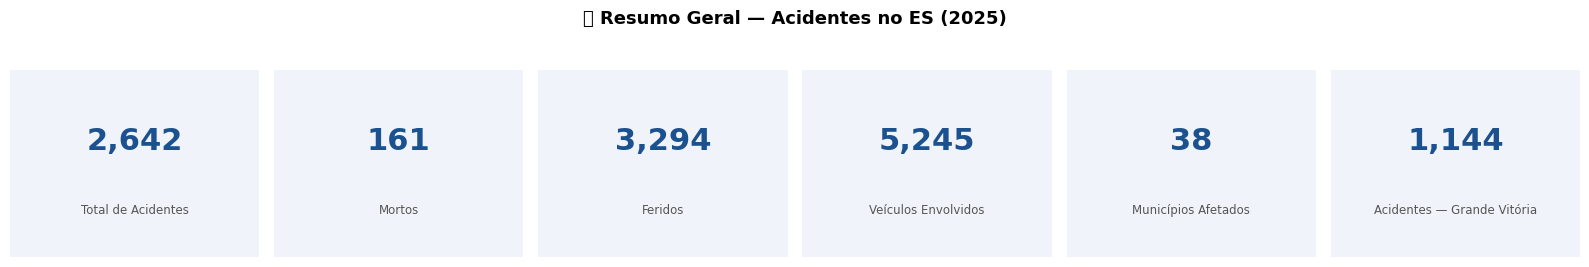

In [ ]:
kpis = {
    'Total de Acidentes': len(df),
    'Mortos':             df['mortos'].sum(),
    'Feridos':            df['feridos'].sum(),
    'Veículos Envolvidos':df['veiculos'].sum(),
    'Municípios Afetados':df['municipio'].nunique(),
    'Acidentes — Grande Vitória': df['grande_vitoria'].sum(),
}

fig, axes = plt.subplots(1, len(kpis), figsize=(16, 2.5))
for ax, (label, valor) in zip(axes, kpis.items()):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0,0),1,1, color='#F0F4FA', transform=ax.transAxes, zorder=0))
    ax.text(0.5, 0.62, f'{valor:,}', ha='center', va='center',
            fontsize=22, fontweight='bold', color=COR_PRINCIPAL, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=8.5, color='#555', transform=ax.transAxes, wrap=True)

plt.suptitle('Resumo Geral — Acidentes no ES (2025)', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 4. Análise Temporal

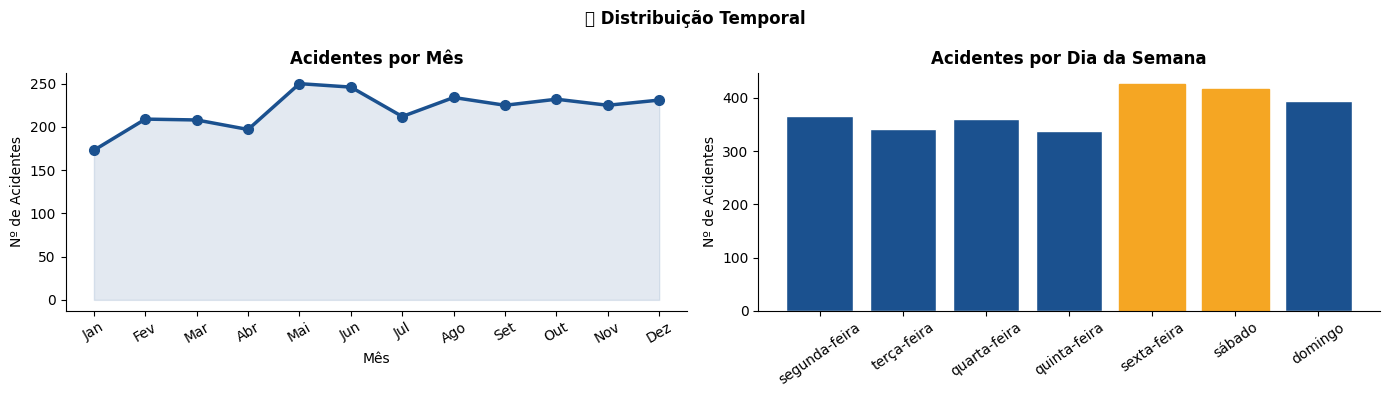

📌 Mês com mais acidentes: Mai
📌 Dia com mais acidentes: sexta-feira (426 ocorrências)


In [ ]:
#Acidentes por mes
por_mes = df.groupby('mes').size().reset_index(name='acidentes')
nomes_mes = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
             7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
por_mes['mes_nome'] = por_mes['mes'].map(nomes_mes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

#Linha por mes
ax1.plot(por_mes['mes_nome'], por_mes['acidentes'],
         marker='o', color=COR_PRINCIPAL, linewidth=2.5, markersize=7)
ax1.fill_between(por_mes['mes_nome'], por_mes['acidentes'], alpha=0.12, color=COR_PRINCIPAL)
ax1.set_title('Acidentes por Mês', fontweight='bold')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Nº de Acidentes')
ax1.tick_params(axis='x', rotation=30)

#Por dia da semana
ordem_dias = ['segunda-feira','terça-feira','quarta-feira','quinta-feira',
              'sexta-feira','sábado','domingo']
por_dia = df['dia_semana'].value_counts().reindex(ordem_dias, fill_value=0)
bars = ax2.bar(por_dia.index, por_dia.values, color=COR_PRINCIPAL, edgecolor='white')
bars[4].set_color(COR_ACENTO)  #destaca sexta
bars[5].set_color(COR_ACENTO)  #destaca sabado
ax2.set_title('Acidentes por Dia da Semana', fontweight='bold')
ax2.set_ylabel('Nº de Acidentes')
ax2.tick_params(axis='x', rotation=35)

plt.suptitle('Distribuição Temporal', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mês com mais acidentes: {nomes_mes[por_mes.loc[por_mes.acidentes.idxmax(),"mes"]]}')
print(f'Dia com mais acidentes: {por_dia.idxmax()} ({por_dia.max()} ocorrências)')

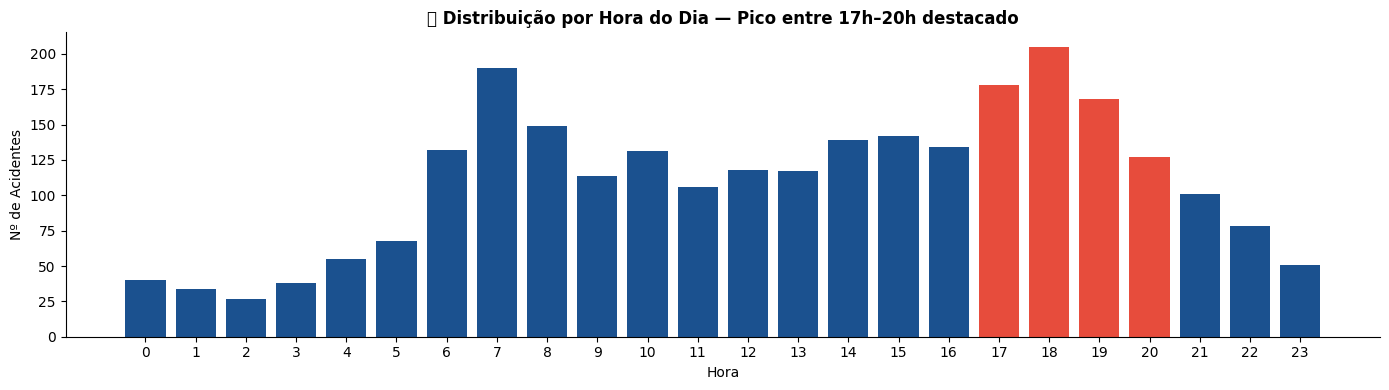

📌 Hora de maior incidência: 18h (205 acidentes)


In [ ]:
#Distribuicao por hora do dia
por_hora = df['hora'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
colors = [COR_PERIGO if h in range(17,21) else COR_PRINCIPAL for h in por_hora.index]
ax.bar(por_hora.index, por_hora.values, color=colors, width=0.8)
ax.set_title('Distribuição por Hora do Dia — Pico entre 17h–20h destacado', fontweight='bold')
ax.set_xlabel('Hora')
ax.set_ylabel('Nº de Acidentes')
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.show()

hora_pico = por_hora.idxmax()
print(f'Hora de maior incidência: {hora_pico}h ({por_hora.max()} acidentes)')

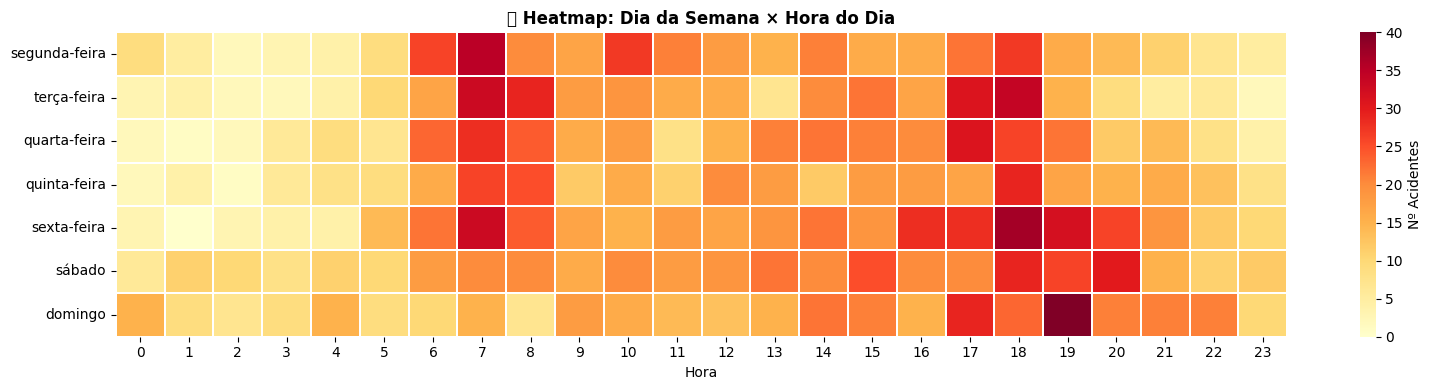

In [ ]:
#Heatmap dia x hora
df['hora_int'] = pd.to_numeric(df['hora'], errors='coerce')
heatmap_data = df.groupby(['dia_semana','hora_int']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(ordem_dias, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Nº Acidentes'})
ax.set_title('Heatmap: Dia da Semana × Hora do Dia', fontweight='bold')
ax.set_xlabel('Hora')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Análise Espacial

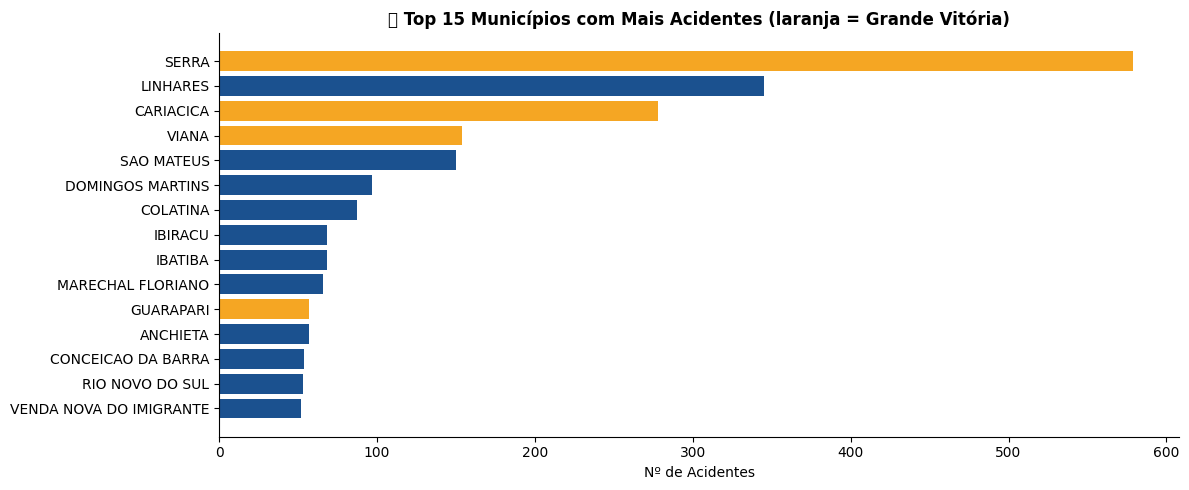

In [ ]:
#Top 15 municipios com mais acidentes
top_municipios = df['municipio'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [COR_ACENTO if m in GRANDE_VITORIA else COR_PRINCIPAL for m in top_municipios.index]
ax.barh(top_municipios.index[::-1], top_municipios.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Municípios com Mais Acidentes (laranja = Grande Vitória)', fontweight='bold')
ax.set_xlabel('Nº de Acidentes')
plt.tight_layout()
plt.show()

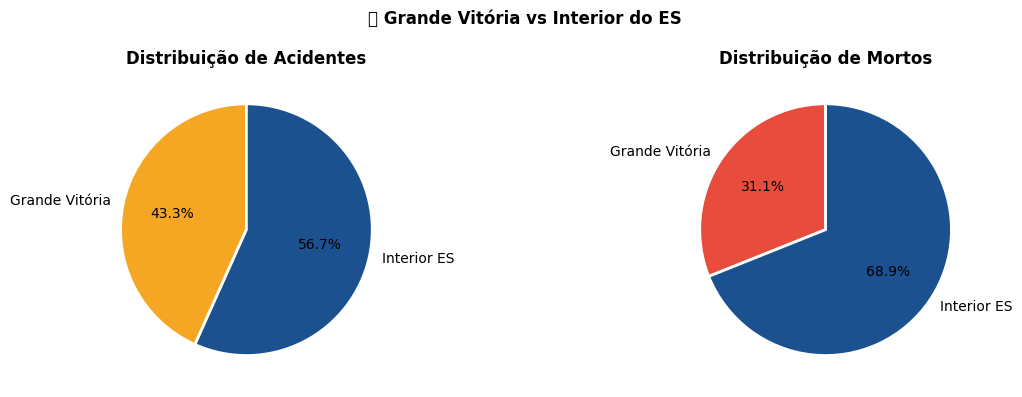

📌 Grande Vitória: 1144 acidentes (43.3%) e 50 mortos
📌 Interior ES:    1498 acidentes (56.7%) e 111 mortos


In [ ]:
#Comparativo: Grande Vitoria vs Interior
gv_total    = df['grande_vitoria'].sum()
int_total   = len(df) - gv_total
gv_mortos   = df[df['grande_vitoria']]['mortos'].sum()
int_mortos  = df[~df['grande_vitoria']]['mortos'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Pizza acidentes
axes[0].pie([gv_total, int_total],
            labels=['Grande Vitória', 'Interior ES'],
            colors=[COR_ACENTO, COR_PRINCIPAL],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribuição de Acidentes', fontweight='bold')

#Pizza mortos
axes[1].pie([gv_mortos, int_mortos],
            labels=['Grande Vitória', 'Interior ES'],
            colors=[COR_PERIGO, COR_PRINCIPAL],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Distribuição de Mortos', fontweight='bold')

plt.suptitle('Grande Vitória vs Interior do ES', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Grande Vitória: {gv_total} acidentes ({gv_total/len(df)*100:.1f}%) e {gv_mortos} mortos')
print(f'Interior ES:    {int_total} acidentes ({int_total/len(df)*100:.1f}%) e {int_mortos} mortos')

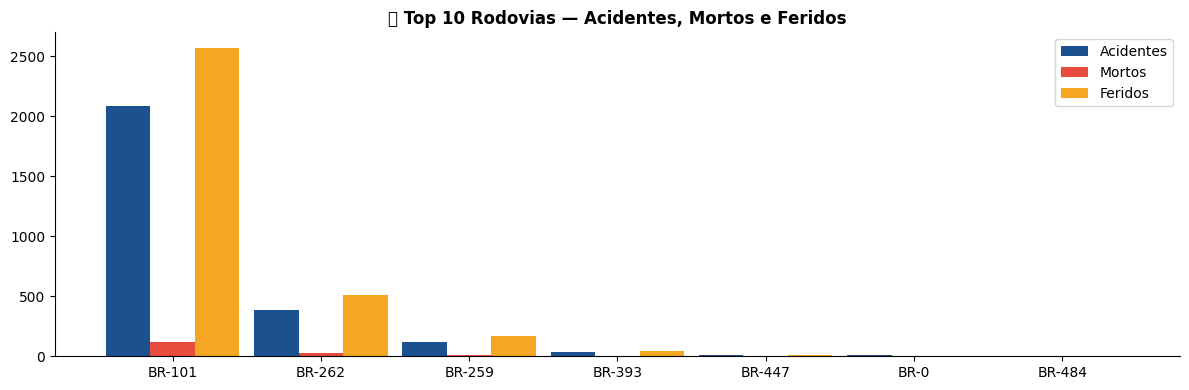

In [ ]:
#Rodovias mais perigosas
top_br = df.groupby('br').agg(
    acidentes=('id','count'),
    mortos=('mortos','sum'),
    feridos=('feridos','sum')
).sort_values('acidentes', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(top_br))
width = 0.3
ax.bar(x - width, top_br['acidentes'], width, label='Acidentes', color=COR_PRINCIPAL)
ax.bar(x,         top_br['mortos'],    width, label='Mortos',    color=COR_PERIGO)
ax.bar(x + width, top_br['feridos'],   width, label='Feridos',   color=COR_ACENTO)
ax.set_xticks(x)
ax.set_xticklabels([f'BR-{int(b)}' for b in top_br.index])
ax.set_title('Top 10 Rodovias — Acidentes, Mortos e Feridos', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Análise Causal

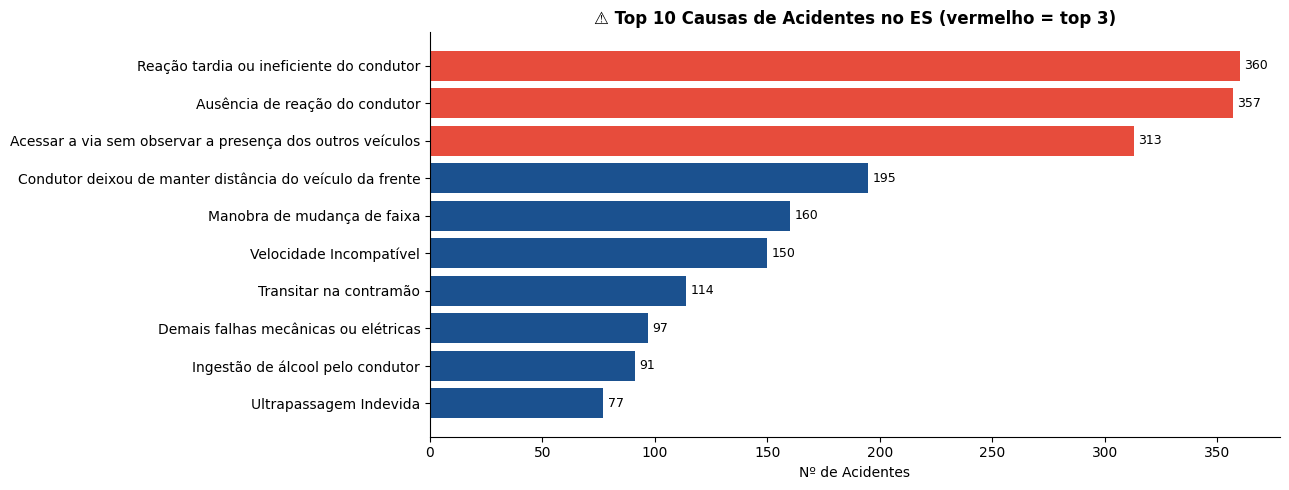

In [ ]:
#Top 10 causas de acidentes
top_causas = df['causa_acidente'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(top_causas.index[::-1], top_causas.values[::-1],
        color=[COR_PERIGO if i < 3 else COR_PRINCIPAL for i in range(len(top_causas)-1, -1, -1)])
ax.set_title('Top 10 Causas de Acidentes no ES (vermelho = top 3)', fontweight='bold')
ax.set_xlabel('Nº de Acidentes')
for i, v in enumerate(top_causas.values[::-1]):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

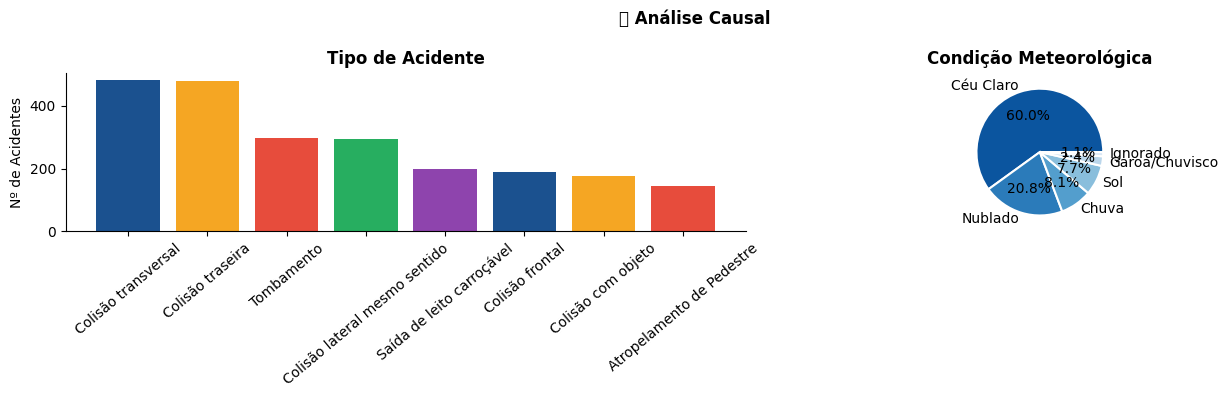

In [ ]:
#Tipo de acidente
top_tipos = df['tipo_acidente'].value_counts().head(8)

#Condicao meteorologica
top_meteo = df['condicao_metereologica'].value_counts().head(6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(top_tipos.index, top_tipos.values, color=PALETTE[:len(top_tipos)])
ax1.set_title('Tipo de Acidente', fontweight='bold')
ax1.tick_params(axis='x', rotation=40)
ax1.set_ylabel('Nº de Acidentes')

ax2.pie(top_meteo.values, labels=top_meteo.index, autopct='%1.1f%%',
        colors=sns.color_palette('Blues_r', len(top_meteo)),
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax2.set_title('Condição Meteorológica', fontweight='bold')

plt.suptitle('Análise Causal', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

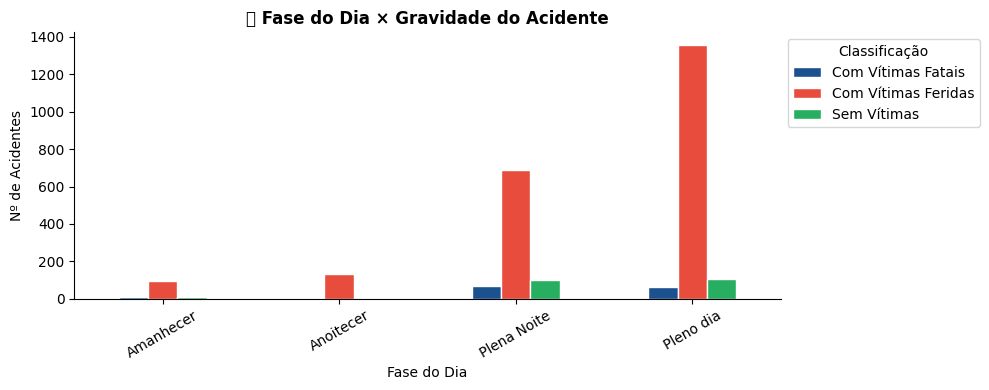

In [ ]:
#Fase do dia × Classificacao
cross = pd.crosstab(df['fase_dia'], df['classificacao_acidente'])

fig, ax = plt.subplots(figsize=(10, 4))
cross.plot(kind='bar', ax=ax, color=[COR_PRINCIPAL, COR_PERIGO, '#27AE60'], edgecolor='white')
ax.set_title('Fase do Dia × Gravidade do Acidente', fontweight='bold')
ax.set_xlabel('Fase do Dia')
ax.set_ylabel('Nº de Acidentes')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Classificação', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

## 7. Machine Learning — Classificação de Risco

Objetivo: prever se um acidente tem **alto risco** (vítimas fatais) ou **baixo/médio risco**, com base nas características do evento.

In [ ]:
#Features e target
features = ['dia_semana', 'fase_dia', 'condicao_metereologica',
            'tipo_pista', 'tracado_via', 'causa_acidente',
            'tipo_acidente', 'uso_solo', 'veiculos', 'pessoas', 'hora']

df_ml = df[features + ['risco']].dropna()

#Variaveis categoricas
cat_cols = [
    'dia_semana',
    'fase_dia',
    'condicao_metereologica',
    'tipo_pista',
    'tracado_via',
    'causa_acidente',
    'tipo_acidente',
    'uso_solo'
]

#Garantir que hora seja numerica
df_ml['hora'] = pd.to_numeric(df_ml['hora'], errors='coerce').fillna(0)

#Criar X e y
X = df_ml[features]
y = df_ml['risco']

#One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print(f'Classes: {df_ml["risco"].value_counts().to_dict()}')

✅ Treino: 1981 amostras | Teste: 661 amostras
   Classes: {'Baixo/Médio Risco': 2497, 'Alto Risco': 145}


In [ ]:
#Treinar Random Forest
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo: {acc*100:.1f}%')
print()
print(classification_report(
    y_test,
    y_pred,
    labels=['Alto Risco','Baixo/Médio Risco']
))

🎯 Acurácia do modelo: 93.5%

                   precision    recall  f1-score   support

       Alto Risco       0.33      0.02      0.04        42
Baixo/Médio Risco       0.94      1.00      0.97       619

         accuracy                           0.93       661
        macro avg       0.64      0.51      0.51       661
     weighted avg       0.90      0.93      0.91       661



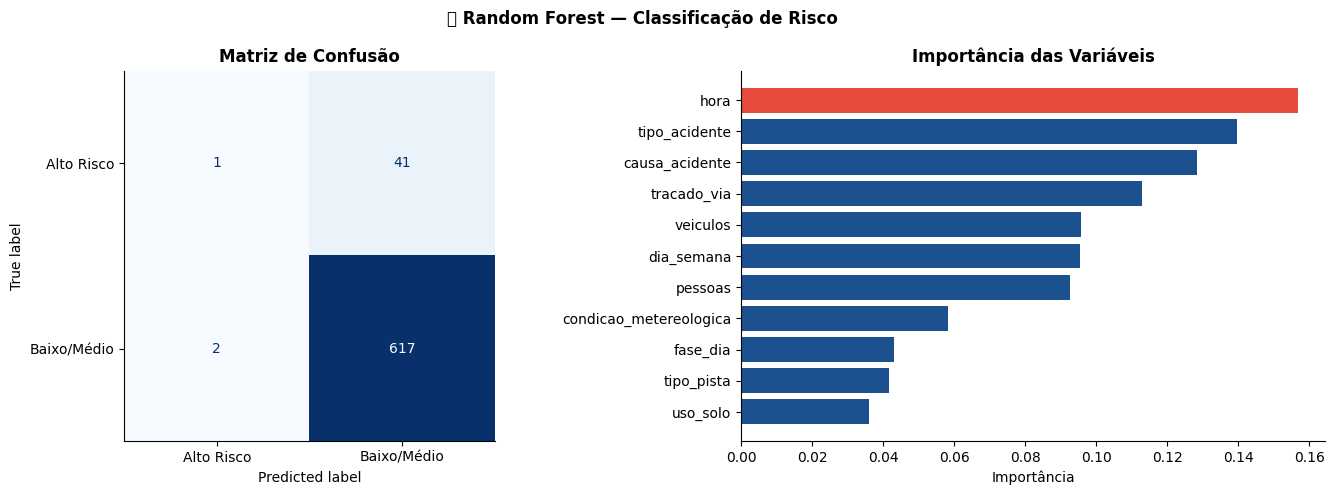

📌 Variável mais importante: hora (0.157)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Matriz de confusao
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Alto Risco', 'Baixo/Médio'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matriz de Confusão', fontweight='bold')

#Importancia das features
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
colors_fi = [COR_PERIGO if importances[f] == importances.max() else COR_PRINCIPAL for f in importances.index]
ax2.barh(importances.index, importances.values, color=colors_fi)
ax2.set_title('Importância das Variáveis', fontweight='bold')
ax2.set_xlabel('Importância')

plt.suptitle('Random Forest — Classificação de Risco', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Variável mais importante: {importances.idxmax()} ({importances.max():.3f})')

## 8. Conclusões

In [ ]:
print('=' * 60)
print('  CONCLUSÕES — Análise de Acidentes de Trânsito ES (2025)')
print('=' * 60)
print()
print(f'VISÃO GERAL')
print(f'   • {len(df):,} acidentes registrados no ES em 2025')
print(f'   • {df["mortos"].sum()} mortos e {df["feridos"].sum():,} feridos')
print(f'   • {df["municipio"].nunique()} municípios afetados')
print()
print(f'PADRÃO TEMPORAL')
print(f'   • Sexta-feira e sábado concentram mais acidentes')
hora_pico = df['hora'].value_counts().idxmax()
print(f'   • Hora de pico: {hora_pico}h')
print(f'   • Pleno dia tem mais acidentes, mas noite tem maior letalidade')
print()
print(f'PADRÃO ESPACIAL')
top3_mun = df["municipio"].value_counts().head(3).index.tolist()
print(f'   • Municípios críticos: {top3_mun}')
top1_br = df.groupby("br")["mortos"].sum().idxmax()
print(f'   • Rodovia com mais mortos: BR-{int(top1_br)}')
print()
print(f'CAUSAS PRINCIPAIS')
top3_causas = df["causa_acidente"].value_counts().head(3).index.tolist()
for i, c in enumerate(top3_causas, 1):
    print(f'   {i}. {c}')
print()
print(f'MACHINE LEARNING')
print(f'   • Modelo Random Forest com acurácia de {acc*100:.1f}%')
print(f'   • Melhor preditor de risco: {importances.idxmax()}')
print()
print('=' * 60)

  CONCLUSÕES — Análise de Acidentes de Trânsito ES (2025)

📊 VISÃO GERAL
   • 2,642 acidentes registrados no ES em 2025
   • 161 mortos e 3,294 feridos
   • 38 municípios afetados

📅 PADRÃO TEMPORAL
   • Sexta-feira e sábado concentram mais acidentes
   • Hora de pico: 18h
   • Pleno dia tem mais acidentes, mas noite tem maior letalidade

📍 PADRÃO ESPACIAL
   • Municípios críticos: ['SERRA', 'LINHARES', 'CARIACICA']
   • Rodovia com mais mortos: BR-101

⚠️ CAUSAS PRINCIPAIS
   1. Reação tardia ou ineficiente do condutor
   2. Ausência de reação do condutor
   3. Acessar a via sem observar a presença dos outros veículos

🤖 MACHINE LEARNING
   • Modelo Random Forest com acurácia de 93.5%
   • Melhor preditor de risco: hora

